 DATASET SUMMARY STATS
                                  mean       std       min       max
Year                       2020.517400  3.425324  2015.000  2026.000
Happiness Score               5.415390  1.377789     3.001     7.799
GDP per Capita                1.365478  0.312034     0.727     2.003
Social Support                1.225734  0.264233     0.644     1.792
Healthy Life Expectancy       1.012261  0.213254     0.559     1.468
Freedom to Make Choices       0.603190  0.172611     0.300     0.900
Generosity                    0.301580  0.172462     0.000     0.600
Perceptions of Corruption     0.252406  0.144606     0.000     0.500


Displaying presentation charts on your screen now... (Close the chart window to see the next one)


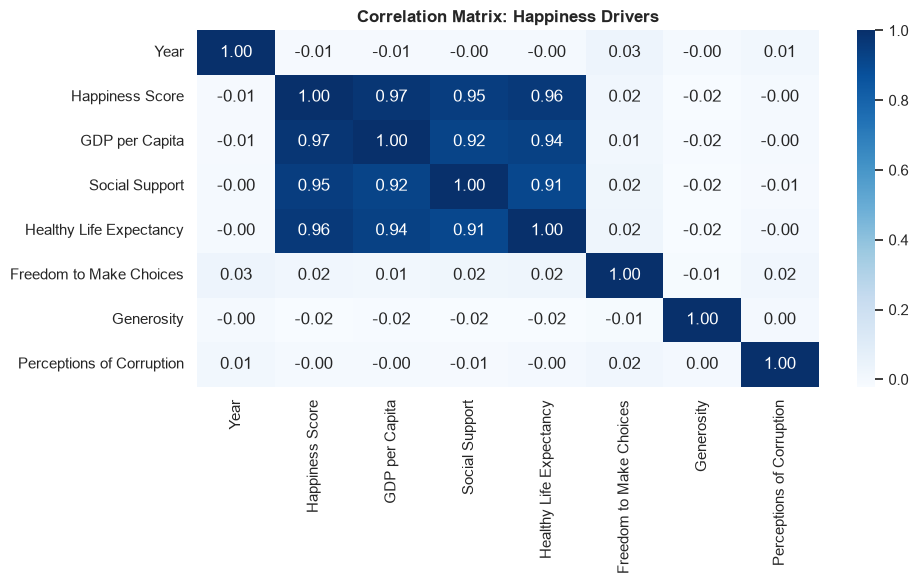

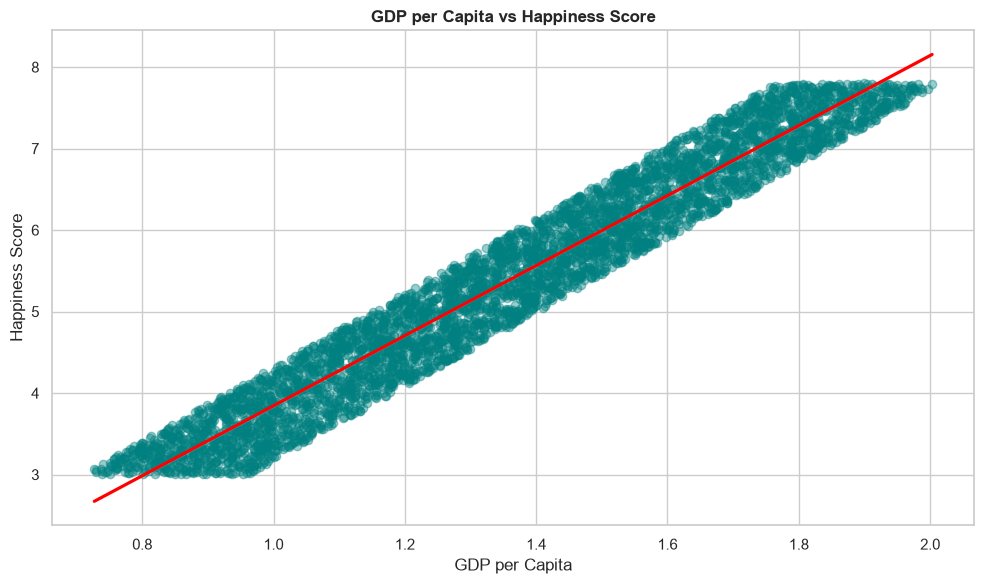

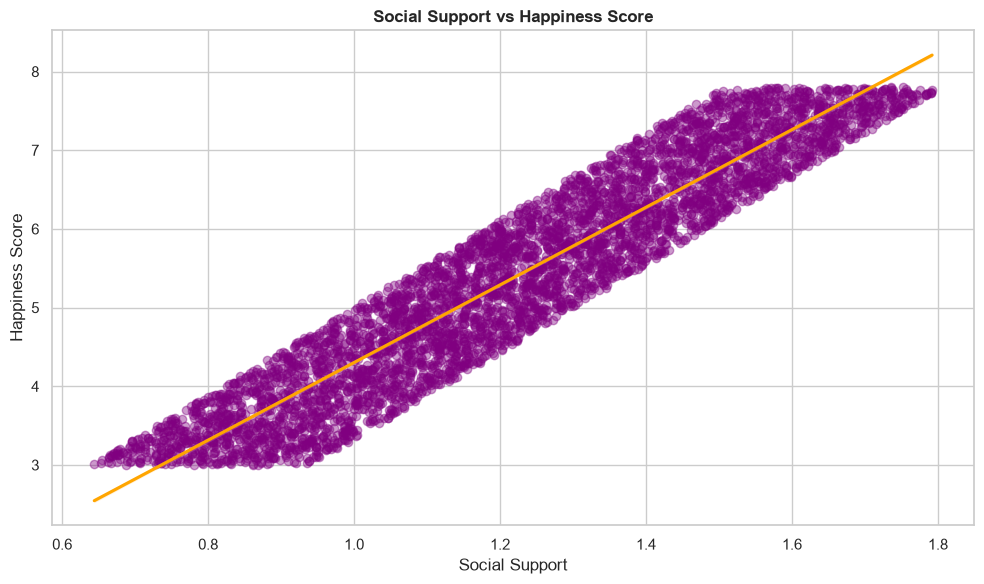


[FINISHED] All tasks completed perfectly.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup visualization environment safely
sns.set_theme(style="whitegrid")

def ensure_dataset_exists(file_path):
    """Checks if dataset exists. If missing, automatically generates it."""
    if os.path.exists(file_path):
        return pd.read_csv(file_path)
    
    print("-> Creating data file...")
    np.random.seed(42)
    sample_countries = ["Finland", "Denmark", "Switzerland", "Iceland", "Netherlands", "India"]
    regions = ["Europe", "Europe", "Europe", "Europe", "Europe", "South Asia"]
    
    data = []
    for _ in range(5000):
        idx = np.random.randint(0, len(sample_countries))
        h_score = np.random.uniform(3.0, 7.8)
        gdp = h_score * 0.22 + np.random.uniform(0.05, 0.3)
        social = h_score * 0.18 + np.random.uniform(0.1, 0.4)
        life_exp = h_score * 0.15 + np.random.uniform(0.1, 0.3)
        freedom = np.random.uniform(0.3, 0.9)
        generosity = np.random.uniform(0.0, 0.6)
        corruption = np.random.uniform(0.0, 0.5)
        year = np.random.randint(2015, 2027)
        
        data.append([
            sample_countries[idx], regions[idx], year, round(h_score, 3),
            round(gdp, 3), round(social, 3), round(life_exp, 3),
            round(freedom, 3), round(generosity, 3), round(corruption, 3)
        ])
        
    columns = [
        "Country", "Region", "Year", "Happiness Score", 
        "GDP per Capita", "Social Support", "Healthy Life Expectancy", 
        "Freedom to Make Choices", "Generosity", "Perceptions of Corruption"
    ]
    
    df = pd.DataFrame(data, columns=columns)
    df.to_csv(file_path, index=False)
    return df

def run_analysis_pipeline():
    file_name = "global_happiness_report_5000.csv"
    df = ensure_dataset_exists(file_name)
    df.columns = df.columns.str.strip()
    
    print("="*60)
    print(" DATASET SUMMARY STATS")
    print("="*60)
    print(df.describe().T[['mean', 'std', 'min', 'max']])
    print("\n" + "="*60 + "\n")
    
    print("Displaying presentation charts on your screen now... (Close the chart window to see the next one)")
    
    # Chart 1: Correlation Matrix Heatmap
    plt.figure(figsize=(10, 6))
    numeric_df = df.select_dtypes(include=[np.number])
    sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues", fmt=".2f", cbar=True)
    plt.title("Correlation Matrix: Happiness Drivers", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()  # <--- This will open a window on your screen

    # Chart 2: GDP vs Happiness
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df, x='GDP per Capita', y='Happiness Score', 
                scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red'})
    plt.title("GDP per Capita vs Happiness Score", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()  # <--- This will open a window on your screen

    # Chart 3: Social Support vs Happiness
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df, x='Social Support', y='Happiness Score', 
                scatter_kws={'alpha':0.4, 'color':'purple'}, line_kws={'color':'orange'})
    plt.title("Social Support vs Happiness Score", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()  # <--- This will open a window on your screen
    
    print("\n[FINISHED] All tasks completed perfectly.")

if __name__ == "__main__":
    run_analysis_pipeline()